In [2]:
import numpy as np
import matplotlib.pyplot as plt
from SpaceBalls.sph_meshing import Grid, RegularLatLonGrid, QuadratureGrid, KnockeGridMONTE
from SpaceBalls.plotter import Plotter
from config.constants import earth_radius
RE = earth_radius()

def add_gray_sphere(ax):
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    f = 0.995  # Keep surface slightly smaller than 1.0 to avoid clipping/Z-fighting
    x = np.outer(np.cos(u), np.sin(v)) * f
    y = np.outer(np.sin(u), np.sin(v)) * f
    z = np.outer(np.ones(np.size(u)), np.cos(v)) * f

    # Explicitly set zorder=1 for the background sphere
    ax.plot_surface(x, y, z, color='lightblue', alpha=0.1, 
                    edgecolor='none', rcount=300, ccount=300, antialiased=True, zorder=1)

def get_camera_vector(elev, azim):
    """Calculates the 3D unit vector pointing from the origin to the camera."""
    e = np.radians(elev)
    a = np.radians(azim)
    return np.array([
        np.cos(e) * np.cos(a),
        np.cos(e) * np.sin(a),
        np.sin(e)
    ])

def filter_front_facing(x, y, z, cam_vec):
    """Masks out coordinates that fall on the back hemisphere relative to the camera."""
    # Dot product: positive values mean the point faces the camera
    dot_product = x * cam_vec[0] + y * cam_vec[1] + z * cam_vec[2]
    
    # Replace hidden points with NaN so Matplotlib breaks the line cleanly
    x_visible = np.where(dot_product >= 0, x, np.nan)
    y_visible = np.where(dot_product >= 0, y, np.nan)
    z_visible = np.where(dot_product >= 0, z, np.nan)
    return x_visible, y_visible, z_visible

def add_equator_and_poles(ax):
    # Grab the current viewing angles from the axis
    cam_vec = get_camera_vector(ax.elev, ax.azim)
    f_lines = 1  # Hair-thin clearance above the sphere surface

    # 1. Equator
    eq_theta = np.linspace(0, 2 * np.pi, 200)
    eq_x = np.cos(eq_theta) * f_lines
    eq_y = np.sin(eq_theta) * f_lines
    eq_z = np.zeros_like(eq_theta)
    ex, ey, ez = filter_front_facing(eq_x, eq_y, eq_z, cam_vec)
    ax.plot(ex, ey, ez, color="k", linestyle="-", linewidth=1.0, zorder=3)
    
    # 2. Poles (Only render if they point toward the camera)
    if f_lines * cam_vec[2] >= 0:  # North Pole check
        ax.scatter(0, 0, f_lines, color="black", marker="x", s=40, linewidths=1.5, zorder=4)
    if -f_lines * cam_vec[2] >= 0: # South Pole check
        ax.scatter(0, 0, -f_lines, color="black", marker="x", s=40, linewidths=1.5, zorder=4)

    # 3. Meridians (Lines of longitude)
    n_meridians = 36
    for i in range(n_meridians):
        theta = (i / n_meridians) * 2 * np.pi
        meridian_phi = np.linspace(0, np.pi, 200)
        meridian_x = np.sin(meridian_phi) * np.cos(theta) * f_lines
        meridian_y = np.sin(meridian_phi) * np.sin(theta) * f_lines
        meridian_z = np.cos(meridian_phi) * f_lines
        
        mx, my, mz = filter_front_facing(meridian_x, meridian_y, meridian_z, cam_vec)
        ax.plot(mx, my, mz, color="gray", linestyle="--", linewidth=0.5, alpha=0.7, zorder=2)
    
    # 4. Parallels (Lines of latitude)
    n_parallels = 17
    for i in range(1, n_parallels + 1):
        phi = (i / (n_parallels + 1)) * np.pi
        parallel_theta = np.linspace(0, 2 * np.pi, 200)
        parallel_x = np.sin(phi) * np.cos(parallel_theta) * f_lines
        parallel_y = np.sin(phi) * np.sin(parallel_theta) * f_lines
        parallel_z = np.cos(phi) * np.ones_like(parallel_theta) * f_lines
        
        px, py, pz = filter_front_facing(parallel_x, parallel_y, parallel_z, cam_vec)
        ax.plot(px, py, pz, color="k", linestyle="--", linewidth=0.5, alpha=0.5, zorder=2)

def plot_grid(ax, grid: Grid, vmin=None, vmax=None):

    cam_vec = get_camera_vector(ax.elev, ax.azim)
    grid_x, grid_y, grid_z = grid.stacked_grid_u[:,0], grid.stacked_grid_u[:,1], grid.stacked_grid_u[:,2]
    grid_x, grid_y, grid_z = filter_front_facing(grid_x, grid_y, grid_z, cam_vec)
    scale_f = grid.n_points / grid.total_area
    scatter = ax.scatter(
        grid_x, grid_y, grid_z,
        c=grid.integration_weights*scale_f,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
        s=20,
        edgecolor=None,
        alpha=1,
        zorder=3,
        depthshade=True
    )

    return scatter

def format_axis(ax):
    ax.set_box_aspect([1,1,1])
    ax.set_xlim([-0.7, 0.7])
    ax.set_ylim([-0.7, 0.7])
    ax.set_zlim([-0.7, 0.7])

    ax.axis("off")

<>:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:14: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:14: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

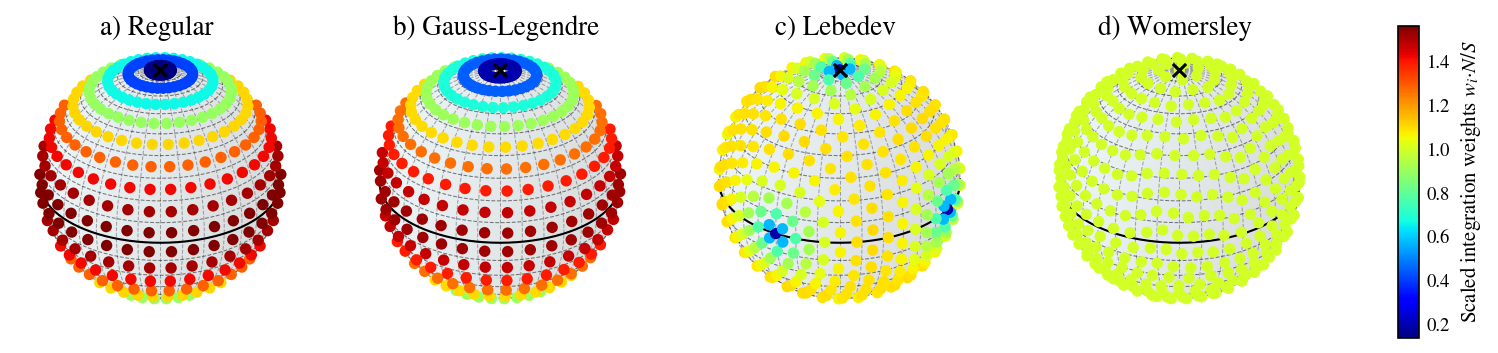

In [ ]:
fig, axes = plt.subplots(
    1, 4, figsize=(14, 4.5), subplot_kw={"projection": "3d",
                                         "computed_zorder": False}
)
n_lat, n_lon = 18, 36
order_leb = 41
order_wom = 35
grids = [RegularLatLonGrid(alt_km=-RE+1, n_lat=n_lat, n_lon=n_lon),
         RegularLatLonGrid(alt_km=-RE+1, lmax=int(np.round(0.25*(-3+np.sqrt(1+8*n_lat*n_lon)))), quad_type='GLQ'),
         QuadratureGrid(alt_km=-RE+1, order=order_leb), # 43.7
         QuadratureGrid(alt_km=-RE+1, order=order_wom, default_womersley=True)]
titles = [
    f"a) Regular\n$N={grids[0].n_points}$;    $l_\max={int(n_lat/2-1)}$",
    f"b) Gauss-Legendre\n$N={grids[1].n_points}$;    $l_\max={n_lat-1}$",
    f"c) Lebedev\n$N={grids[2].n_points}$;    $l_\max={order_leb}$",
    f"d) Womersley\n$N={grids[3].n_points}$;    $l_\max={order_wom}$"
]

vmin = min(grid.integration_weights.min()*grid.n_points / grid.total_area for grid in grids)
vmax = max(grid.integration_weights.max()*grid.n_points / grid.total_area for grid in grids)

for i, ax in enumerate(axes):
    add_gray_sphere(ax)
    add_equator_and_poles(ax)
    format_axis(ax)
    scatter = plot_grid(ax, grids[i], vmin=vmin, vmax=vmax)
    ax.set_title(titles[i], fontsize=11, pad=10, linespacing=1.5)
    #ax.set_title(titles[i], fontsize=13, pad=0, linespacing=1.5)


cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), shrink=0.6, pad=0.05, aspect=15)# , format="{x:.2e}")
cbar.set_label('Scaled integration weights $w_i · N/S$')

In [3]:
fig.savefig("quadrature_grids.pdf", format="pdf", bbox_inches="tight")

<>:14: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:16: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:17: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:14: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

pause


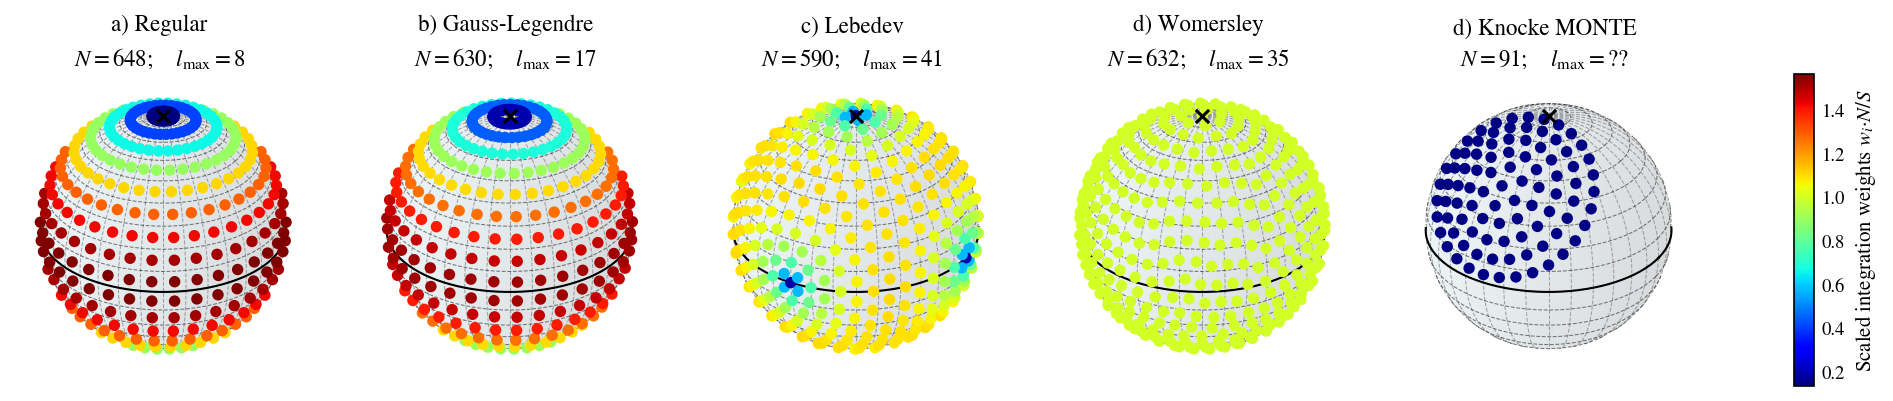

In [9]:
fig, axes = plt.subplots(
    1, 5, figsize=(18, 4.5), subplot_kw={"projection": "3d",
                                         "computed_zorder": False}
)
n_lat, n_lon = 18, 36
order_leb = 41
order_wom = 35
grids = [RegularLatLonGrid(alt_km=-RE+1, n_lat=n_lat, n_lon=n_lon),
         RegularLatLonGrid(alt_km=-RE+1, lmax=int(np.round(0.25*(-3+np.sqrt(1+8*n_lat*n_lon)))), quad_type='GLQ'),
         QuadratureGrid(alt_km=-RE+1, order=order_leb), # 43.7
         QuadratureGrid(alt_km=-RE+1, order=order_wom, default_womersley=True),
         KnockeGridMONTE(r_sat_0=np.array([0,-2,2]), n_rings=5, alt_km=-RE+2)]
titles = [
    f"a) Regular\n$N={grids[0].n_points}$;    $l_\max={int(n_lat/2-1)}$",
    f"b) Gauss-Legendre\n$N={grids[1].n_points}$;    $l_\max={n_lat-1}$",
    f"c) Lebedev\n$N={grids[2].n_points}$;    $l_\max={order_leb}$",
    f"d) Womersley\n$N={grids[3].n_points}$;    $l_\max={order_wom}$",
    f"d) Knocke MONTE\n$N={grids[4].n_points}$;    $l_\max=??$"
]
vmin = min(grid.integration_weights.min()*grid.n_points / grid.total_area for grid in grids)
vmax = max(grid.integration_weights.max()*grid.n_points / grid.total_area for grid in grids)

for i, ax in enumerate(axes):
    add_gray_sphere(ax)
    add_equator_and_poles(ax)
    format_axis(ax)
    scatter = plot_grid(ax, grids[i], vmin=vmin, vmax=vmax)
    ax.set_title(titles[i], fontsize=11, pad=10, linespacing=1.5)


cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), shrink=0.6, pad=0.05, aspect=15)# , format="{x:.2e}")
cbar.set_label('Scaled integration weights $w_i · N/S$')